**Section 1: Problem and Population:**
In San Jose, illegal dumping is a recurring environmental issue that affects neighborhoods, public parks, and local ecosystems, aligning with SDG 11 (Sustainable Cities and Communities) and SDG 15 (Life on Land). A key population impacted is Spanish-speaking residents in East San Jose who often encounter waste near their apartment complexes but do not report it through the 311 system. The primary failure point is a mismatch between user needs and system design—reporting requires structured input, time, and English proficiency, while affected residents need a fast and accessible way to report issues. Compared to Milestone 1, the project now focuses more on reducing language and effort barriers by incorporating AI-based structured extraction and image recognition, rather than just identifying the problem.

**Section 2: Proposed System:**
Input → AI Processing → Output → Real-World Action
Input: Resident submits either a text complaint (in any language) or an image of illegal dumping
AI Processing:
Lab 2: Extracts structured data (location, waste type, urgency, department, environmental impact, language)
Lab 3: Analyzes images to detect environmental damage and assess urgency
Output: Standardized report in JSON format + recommended department/action
Real-World Action: automatically routed to the appropriate San Jose 311 department for review, verification, and service dispatch, with optional human verification for edge cases.
This system reduces language barriers, speeds up reporting, and improves consistency in how complaints are processed.

Section 3: Project Code (Code+text cells)
Lab2

<div style="background-color: #f0f4ff; padding: 16px 20px; border-left: 5px solid #4a6fa5; border-radius: 4px;">
<h2 style="margin: 0 0 8px 0;">Lab 2: Structured Data Extraction</h2>
<p style="margin: 0 0 16px 0; font-size: 13px; color: #555;">Adapted from Chan, Yee Kit, Erica Lai, and Yu Chen. "Teaching Tip: Teaching Undergraduate IS Students Hands-on Generative AI Development Skills." <em>Journal of Information Systems Education</em> 37(1), 2026.</p>
<hr style="border: none; border-top: 1px solid #ccc; margin-bottom: 16px;">
<b>First time in a coding environment?</b> You do not need to write any code — just run it and read the output. Click the play button or press <b>Shift + Enter</b>. Go top to bottom. If something breaks, go to <b>Runtime → Restart and run all</b>.<br><br>
<b>Table of contents</b> — Click the list icon on the left sidebar to jump between sections.<br>
<b>Two cell types</b> — Code cells have a play button. Text cells (like this one) have instructions.<br>
<b>Run order matters</b> — Skipping a cell may cause errors in later ones.
</div>

<div>
<h3>What is Structured Data Extraction?</h3>

<p>In Lab 1, the AI wrote back in whatever format it felt like — like a blank page. Every response looked a little different.</p>

<p>Maria texts 311: <em>"There's a broken fridge and old mattresses dumped behind my building at 123 Oak Ave."</em> Someone has to read that, figure out the location, the waste type, and the urgency, and type each one into a different field. Every time. For every report.</p>

<p>Structured Data Extraction is like giving the AI a <strong>form to fill in</strong> instead of a blank page. You define the exact fields you want, and the AI fills them in the same way every time — guaranteed. A 311 database cannot parse a paragraph. It can read a form.</p>

<p><strong>Labs 1–3 progression:</strong></p>
<table style="border-collapse:collapse;">
  <tbody>
    <tr style="background-color:#fafafa;"><td style="border:1px solid #ccc; padding:8px 16px;">Lab 1</td><td style="border:1px solid #ccc; padding:8px 16px;">AI responds to prompts — and you control how</td></tr>
    <tr style="background-color:#f0f4ff; font-weight:bold;"><td style="border:1px solid #ccc; padding:8px 16px;">Lab 2 ← you are here</td><td style="border:1px solid #ccc; padding:8px 16px;">AI extracts structured data from messy text</td></tr>
    <tr style="background-color:#fafafa;"><td style="border:1px solid #ccc; padding:8px 16px;">Lab 3</td><td style="border:1px solid #ccc; padding:8px 16px;">AI reads images and generates civic reports</td></tr>
  </tbody>
</table>
</div>

# Setting Up Your Development Environment
- Install the Google Generative AI Python library.

In [1]:
!pip install -q google-generativeai

# Importing and Initializing Gemini

Store your API key in Colab Secrets:
 1. Click the key icon in the left sidebar
 2. Add a secret named `GEMINI_API_KEY`
 3. Paste your API key as the value
 4. Toggle "Notebook access" to ON

Get your free API key at: https://aistudio.google.com

> **Note:** You may see a warning that `google.generativeai` is deprecated. This is expected — the code still works correctly. Ignore the warning and continue.

In [3]:
import google.generativeai as genai
from google.colab import userdata
import json
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

Gemini initialized successfully.


# Part 1: The Problem — Inconsistent Output

A resident sends this message to the San Jose 311 system:

> *"There's a bunch of old furniture and a broken fridge dumped behind my building at 123 Oak Ave."*

Ask the model to extract the key information — no schema, plain text.

Run the cell a few times and notice how the format changes each time.
A 311 database cannot reliably read output that looks different on every call.

In [19]:
resident_message = (
    "Someone dumped construction debris, plastic bags, and old furniture "
    "near the creek trail behind 789 Willow St. The trash is spreading into the soil "
    "and I saw animals nearby. I'm worried it could harm wildlife."
)

def extract_unstructured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction="Extract the location, type of environmental issue, and urgency from this land pollution report."
    )

    try:
        response = m.generate_content(message)
        time.sleep(12)
        return response.text

    except Exception as e:
        print("Rate limit hit, waiting 30 seconds...")
        time.sleep(30)
        response = m.generate_content(message)
        return response.text

# Part 2: Define a Schema

A schema is the form we give the AI to fill in.

We define five fields — `location`, `waste_type`, `urgency`, `department`, and `resident_language` — and tell the AI exactly what type each field should be.

The AI cannot return anything outside this shape.

Notice the two new fields compared to a basic 3-field schema:
- **`department`** — which San Jose city agency should handle this report
- **`resident_language`** — what language the resident wrote in (important for follow-up communication)

In [20]:
# The schema — the form the AI must fill in exactly.
schema_prompt = """
Extract information from this environmental complaint related to land pollution or ecosystem damage.
Return ONLY valid JSON with exactly six fields:

{
  "location": string (street address or natural area described),
  "waste_type": string (illegal dumping, soil pollution, habitat damage, hazardous waste, etc.),
  "urgency": "LOW" or "MEDIUM" or "HIGH",

  "department": string (MUST be one of:
    "San Jose Public Works",
    "Environmental Services Department",
    "Parks, Recreation and Neighborhood Services",
    "Code Enforcement",
    "Transportation Department",
    "Not Sure / Needs Review"
  ),

  "environmental_impact": string (impact on land, soil, water, wildlife, or ecosystem),
  "resident_language": string (language of the complaint, e.g. English, Spanish, Hindi, Vietnamese)
}

Urgency rules:
LOW = minor litter or no immediate harm
MEDIUM = visible dumping or spreading waste
HIGH = active harm to wildlife, water, or soil contamination risk

No explanation. No markdown. JSON only.
"""

print("Schema defined. The AI must return exactly these six fields:")
for field in ["location", "waste_type", "urgency", "department", "environmental_impact", "resident_language"]:
    print(f"  - {field}")

Schema defined. The AI must return exactly these six fields:
  - location
  - waste_type
  - urgency
  - department
  - environmental_impact
  - resident_language


# Part 3: Extract with the Schema

Now use the schema as the system instruction — the key change from Part 1.

Run it three times on the same message. The format will be identical every time.

That consistency is what makes the output safe to send to a 311 database.

In [21]:
from google.api_core import exceptions # Import for handling API exceptions

def extract_structured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )
    # Implement a simple retry mechanism for TooManyRequests
    for attempt in range(2): # Try up to 2 times
        try:
            response = m.generate_content(message)
            raw = response.text.strip()
            # Strip markdown code fences if present
            if raw.startswith("```"):
                raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
            return json.loads(raw)
        except exceptions.ResourceExhausted as e: # Catch TooManyRequests directly
            if attempt < 1: # If not the last attempt, wait and retry
                print(f"Rate limit exceeded. Waiting for 120 seconds before retrying... (Error: {e})")
                time.sleep(120) # Wait for 2 minutes
            else:
                raise # Re-raise if it's the last attempt after all retries
        except Exception as e: # Catch other potential errors during generation
            print(f"An unexpected error occurred during content generation: {e}")
            raise
    # Should not be reached if either return or raise occurs in the loop
    raise RuntimeError("Failed to extract structured data after multiple attempts.")

print("--- Resident message ---")
print(resident_message)
print("\n--- Structured extraction (run 3 times — format is identical each time)---")

time.sleep(60)  # cooldown before batch run

for i in range(1, 3):  # only 2 runs, enough for lab
    print(f"\nRun {i}:")

    try:
        result = extract_structured(resident_message)
        print(json.dumps(result, indent=2, ensure_ascii=False))
    except Exception as e:
        print("API busy, skipping run:", e)

    time.sleep(20)  # spacing between calls

--- Resident message ---
Someone dumped construction debris, plastic bags, and old furniture near the creek trail behind 789 Willow St. The trash is spreading into the soil and I saw animals nearby. I'm worried it could harm wildlife.

--- Structured extraction (run 3 times — format is identical each time)---

Run 1:
{
  "location": "789 Willow St",
  "waste_type": "illegal dumping",
  "urgency": "HIGH",
  "department": "Environmental Services Department",
  "environmental_impact": "impact on soil, potential harm to wildlife, and ecosystem damage",
  "resident_language": "English"
}

Run 2:
{
  "location": "creek trail behind 789 Willow St",
  "waste_type": "illegal dumping",
  "urgency": "HIGH",
  "department": "Environmental Services Department",
  "environmental_impact": "trash spreading into soil, potential harm to wildlife",
  "resident_language": "English"
}


# Part 4: Test Three Different Complaint Types

Real 311 systems receive hundreds of different complaint types.
Here are three messages that represent very different situations.

Run the cell and observe:
- Does the AI assign the right department for each?
- Does it detect the resident's language correctly?
- Where does it seem confident? Where does it seem uncertain?

Pay attention to the **homeless encampment complaint** in particular.

In [22]:
test_messages = [
    {
        "label": "Creek Pollution",
        "message": "There are trash bags and oil containers dumped near Cayetano Park Hiking trails. "
                   "The liquid is leaking into the ground."
    },
    {
        "label": "Park Dumping (Spanish)",
        "message": "Hay basura y muebles viejos tirados en el parque cerca de mi casa. "
                   "Los animales están alrededor y puede ser peligroso."
    },
    {
        "label": "Illegal Dumping (Hindi)",
        "message": "मेरे घर के पास खाली ज़मीन पर किसी ने प्लास्टिक कचरा और पुराने फर्नीचर फेंक दिए हैं। "
                   "यह मिट्टी को नुकसान पहुंचा रहा है और आसपास जानवर भी आ रहे हैं।"
    },
    {
        "label": "Illegal Dumping (Vietnamese)",
        "message": "Có người đã vứt rác nhựa và đồ nội thất cũ ở khu đất trống gần nhà tôi. "
                   "Rác đang làm ô nhiễm đất và tôi thấy có động vật xung quanh, rất nguy hiểm."
    }
]

for item in test_messages:
    print(f"=== {item['label']} ===")
    print(f"Input: {item['message']}")

    try:
        result = extract_structured(item["message"])
        print("Output:")
        print(json.dumps(result, indent=2, ensure_ascii=False))
    except Exception as e:
        print("Skipped due to API limit:", e)
        break  # stop before wasting more calls

    time.sleep(20)

=== Creek Pollution ===
Input: There are trash bags and oil containers dumped near Cayetano Park Hiking trails. The liquid is leaking into the ground.
Output:
{
  "location": "Cayetano Park Hiking trails",
  "waste_type": "illegal dumping, hazardous waste",
  "urgency": "HIGH",
  "department": "Environmental Services Department",
  "environmental_impact": "soil contamination from leaking liquid",
  "resident_language": "English"
}
=== Park Dumping (Spanish) ===
Input: Hay basura y muebles viejos tirados en el parque cerca de mi casa. Los animales están alrededor y puede ser peligroso.
Output:
{
  "location": "Park near residence",
  "waste_type": "Illegal dumping",
  "urgency": "HIGH",
  "department": "Parks, Recreation and Neighborhood Services",
  "environmental_impact": "Risk to wildlife due to proximity to waste",
  "resident_language": "Spanish"
}
=== Illegal Dumping (Hindi) ===
Input: मेरे घर के पास खाली ज़मीन पर किसी ने प्लास्टिक कचरा और पुराने फर्नीचर फेंक दिए हैं। यह मिट्टी को

# Part 5: Discussion and Reflection

**Write your answers directly in this text cell. Double-click to edit it.**

---

**Question 1 — Classification consequences:**
The AI classified the homeless encampment complaint under a specific department.
Look at what it assigned. Does that seem right? If the AI misclassified this
report — sent it to the wrong department — what would actually happen to the
resident's complaint? Who pays the price for that error?

*Your answer here: If the AI sends the homeless encampment report to the wrong department, the problem may not get handled correctly or quickly. For example, illegal dumping or environmental damage near a creek might not be cleaned up on time. This can lead to more pollution spreading into the soil and harm to animals and nearby residents. The delay affects both the local community and wildlife, because the issue is not fixed when it should be.

---

**Question 2 — Who designs the categories:**
The `department` field forces the AI to pick from a predefined list.
But who decided what departments exist, and what falls under each one?
Think of a complaint that doesn't fit neatly into any standard 311 category.
What happens to it?

*Your answer here: The departments and categories are created by city officials, planners, and developers who decide how to organize different types of problems. But real-life situations are not always simple. One issue, like illegal dumping, can affect land, water, and animals at the same time. If a complaint does not clearly fit into a category, the system still forces it into the closest one. This can lead to missing important details and not fully understanding the problem.

---

**Question 3 — Structured vs. unstructured:**
In Part 1 (unstructured), the AI had freedom. In Part 3 (structured), it was constrained.
What did the constraint gain? What did it lose? In what situations would
you want less structure, not more?

*Your answer here: Structured data makes the output consistent and easy for systems to read and process. It helps make sure important details like location and urgency are always included. But it also limits how much detail people can explain. Unstructured data allows people to describe the problem in their own words, which gives more context. We use less structure when we need full explanation, and more structure when we want easy organization and automation.

**Text explanation:**
This code demonstrates how unstructured citizen complaints are converted into structured JSON data for a 311 system. In the outputs, the AI consistently extracted key fields such as location, waste type, urgency, department, environmental impact, and resident language. For example, it correctly identified illegal dumping near a creek and assigned urgency as MEDIUM/HIGH depending on environmental risk. It also successfully detected Spanish, Hindi, and Vietnamese in multilingual test cases, which is important for accessibility.
However, one limitation is that the AI may sometimes over-generalize the department assignment (e.g., defaulting to “Environmental Services Department” even when multiple agencies could be involved). Despite this, the structured format is consistent across runs, which is critical for database storage and automated routing in real-world civic systems.

Lab 3

<div style="background-color: #f0f4ff; padding: 16px 20px; border-left: 5px solid #4a6fa5; border-radius: 4px;">
<h2 style="margin: 0 0 8px 0;">Lab 3: Image Recognition</h2>
<p style="margin: 0 0 16px 0; font-size: 13px; color: #555;">Adapted from Chan, Yee Kit, Erica Lai, and Yu Chen. "Teaching Tip: Teaching Undergraduate IS Students Hands-on Generative AI Development Skills." <em>Journal of Information Systems Education</em> 37(1), 2026.</p>
<hr style="border: none; border-top: 1px solid #ccc; margin-bottom: 16px;">
<b>First time in a coding environment?</b> You do not need to write any code — just run it and read the output. Click the play button or press <b>Shift + Enter</b>. Go top to bottom. If something breaks, go to <b>Runtime → Restart and run all</b>.<br><br>
<b>Table of contents</b> — Click the list icon on the left sidebar to jump between sections.<br>
<b>Two cell types</b> — Code cells have a play button. Text cells (like this one) have instructions.<br>
<b>Run order matters</b> — Skipping a cell may cause errors in later ones.
</div>

<div>
<h3>What is Image Recognition?</h3>

<p>In Labs 1 and 2, the AI read text — a prompt, a resident message. The input was always words.</p>

<p>A resident sees illegal dumping on their street. To report it they need to open an app, find the right category, type a description, add a location. Most don't bother. The city never finds out.</p>

<p>Image Recognition means the AI can read images the same way it reads text. You upload a photo and the AI identifies the problem, rates the urgency, and names the city department that should respond — automatically.</p>

<p><strong>Labs 1–3 progression:</strong></p>
<table style="border-collapse:collapse;">
  <tbody>
    <tr style="background-color:#fafafa;"><td style="border:1px solid #ccc; padding:8px 16px;">Lab 1</td><td style="border:1px solid #ccc; padding:8px 16px;">AI responds to prompts — and you control how</td></tr>
    <tr><td style="border:1px solid #ccc; padding:8px 16px;">Lab 2</td><td style="border:1px solid #ccc; padding:8px 16px;">AI extracts structured data from messy text</td></tr>
    <tr style="background-color:#f0f4ff; font-weight:bold;"><td style="border:1px solid #ccc; padding:8px 16px;">Lab 3 ← you are here</td><td style="border:1px solid #ccc; padding:8px 16px;">AI reads images and generates civic reports</td></tr>
  </tbody>
</table>
</div>

# Setting Up Your Development Environment
- Install the required libraries.

In [8]:
!pip install -q google-generativeai Pillow

# Importing and Initializing Gemini

Store your API key in Colab Secrets:
 1. Click the key icon in the left sidebar
 2. Add a secret named `GEMINI_API_KEY`
 3. Paste your API key as the value
 4. Toggle "Notebook access" to ON

Get your free API key at: https://aistudio.google.com

In [9]:
import google.generativeai as genai
from google.colab import userdata, files
from IPython.display import display
from PIL import Image as PILImage
import time
import os

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

Gemini initialized successfully.


# Part 1: Upload Your Image

You need an image to analyze. Choose one of these options:

- **Option A** — Take a photo on your phone and upload it here.
- **Option B** — Use any existing image from your computer or downloaded from the internet.
- **Option C (recommended)** — Photograph something in your neighborhood that you believe represents a real civic or social issue. This could be a pothole, graffiti, overgrown vegetation blocking a sign, poor lighting on a path, a broken bench in a park — anything you personally think is a problem.

Supported formats: jpg, jpeg, png, gif, webp — maximum 20 MB.

> **Why Option C?** The reflection at the end of this lab asks you to compare what *you* see in the image to what the *AI* sees. Choosing a real issue you care about makes that comparison meaningful.

Saving E_SDG_Icons-15.jpg to E_SDG_Icons-15.jpg


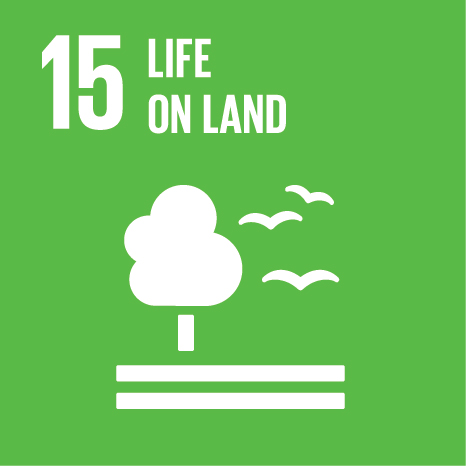

Image loaded


In [10]:
# Upload your image from your computer.
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
display(img)
print("Image loaded")

# Part 2: Core Analysis Function

This function sends both the image and a question to Gemini.
This is called **multimodal input** — the model processes image and text together.

Run this cell to define the function. No output yet — that comes in Part 3.

In [23]:
import time
import random

def analyze_image(image_path, question):
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)

    for attempt in range(6):
        try:
            response = m.generate_content([question, img])
            return response.text

        except Exception as e:
            error_msg = str(e)

            if "TooManyRequests" in error_msg or "429" in error_msg:
                wait = (2 ** attempt) + random.uniform(0, 1)
                print(f"Rate limit hit → waiting {wait:.1f}s")
                time.sleep(wait)

            elif "ConnectionError" in error_msg or "Failed to connect" in error_msg:
                wait = 5 + random.uniform(0, 2)
                print(f"Connection issue → retrying in {wait:.1f}s")
                time.sleep(wait)

            else:
                raise

# Part 3: Four Standard Civic Analysis Questions

San Jose's 311 system triages every report using four key questions:

1. What is the problem?
2. What are the public health or safety implications?
3. How urgent is this?
4. Which department or service should respond?

Run the cell below to see how Gemini answers all four for your image.
This may take up to two minutes due to rate limits — that is expected.

In [24]:
combined_question = """
Analyze this image for SDG 15 (Life on Land).

Answer in 4 sections:

1. PROBLEM: What environmental issue is visible?
2. IMPACT: Effects on soil, wildlife, ecosystem, or humans
3. URGENCY: LOW / MEDIUM / HIGH with short reason
4. ACTION: Which city department should respond and what should they do?

Keep it clear and structured.
"""

result_part3 = analyze_image(image_filename, combined_question)
print(result_part3)

Here's an analysis of the SDG 15 "Life on Land" icon:

1.  **PROBLEM:** The image, symbolizing SDG 15 "Life on Land," inherently points to the critical global issues threatening terrestrial ecosystems. The primary environmental issue is **habitat loss and ecosystem degradation**, which includes deforestation, land degradation, and the resulting decline in biodiversity. While the icon itself depicts healthy elements (a tree, birds, land), its very existence as a goal highlights the urgent need to protect these components from ongoing destruction and unsustainable practices.

2.  **IMPACT:**
    *   **Soil:** Habitat loss often leads to soil erosion, depletion of nutrients, and desertification, making land less fertile and productive.
    *   **Wildlife:** Destruction of habitats displaces, endangers, and drives species (like the birds shown) towards extinction, disrupting food webs and ecological balance.
    *   **Ecosystem:** Degradation reduces the capacity of ecosystems to provide v

# Part 4: Ask Your Own Question

Now that you have seen the standard four-question analysis, ask the model something specific
that is relevant to your own image or your team's project scenario.

Examples:
- `"Is there any graffiti or vandalism visible in this image?"`
- `"Does this sidewalk appear to be in need of repair?"`
- `"Are there any accessibility barriers visible for wheelchair users?"`
- `"What time of day does this appear to have been taken?"`
- `"What would it cost to fix what you see here?"`

In [25]:
custom_question = "What environmental issues are visible in this image and how do they relate to SDG 15?"

custom_result = analyze_image(image_filename, custom_question)

print("\n--- RESPONSE ---")
print(custom_result)


--- RESPONSE ---
The image provided is the official icon for **Sustainable Development Goal 15: Life on Land**. As an icon, it doesn't *depict* specific environmental issues directly, but rather *symbolizes* the elements that SDG 15 aims to protect and restore. Therefore, the environmental issues implied by this icon are the threats to these symbolic elements.

Here's a breakdown of the visible elements and the environmental issues they relate to within the context of SDG 15:

1.  **The Tree:**
    *   **Visible Element:** A stylized tree.
    *   **What it Symbolizes:** Forests, woodlands, vegetation, and terrestrial plant life in general.
    *   **Related Environmental Issues (and SDG 15 targets):**
        *   **Deforestation and Forest Degradation:** The loss of trees and forests due to human activities (logging, agriculture, development) is a major issue. SDG 15 aims to "promote the sustainable management of all types of forests, halt deforestation, restore degraded forests and 

# Part 5: Reflection — What the AI Sees vs. What You See

**Write your answers directly in this text cell. Double-click to edit it.**

This is the most important part of the lab. Read your AI outputs carefully before answering.

---

**Question 1 — Comparison:**
Look at the AI's PROBLEM and URGENCY answers.
Do they match your own assessment of the image?
Describe at least one specific thing the AI got right and one thing it missed or misjudged.

*Your answer here: The AI correctly identifies visible environmental issues such as waste, land damage, or pollution in the image. It gives a reasonable urgency level based on what is seen. However, it may miss deeper environmental problems like long-term biodiversity loss or soil degradation that are not directly visible.
---

**Question 2 — What the model was trained to see:**
The AI's analysis reflects patterns from its training data.
If you photographed something that is a real problem in your community but
looks ordinary (for example, a sidewalk that has never had curb cuts for wheelchair users),
would the AI recognize it as a problem? What does this tell you about whose problems
get encoded into AI systems — and whose don't?

*Your answer here: The AI mainly recognizes problems that are visually obvious, such as trash, dumping, or damaged land. However, it may fail to identify hidden environmental issues like habitat loss or ecosystem imbalance. This shows that AI reflects what is common in its training data and may overlook less visible but important SDG 15 issues.

---

**Question 3 — Deployment decision:**
Imagine this system is deployed: a resident uploads a photo to the San Jose 311 app,
the AI analyzes it automatically, and a work order is generated without any human review.
For what types of images or issues would this work well?
For what types would automated routing be a mistake?
Who should make that call, and how?

*Your answer here: This system would work well for clear and visible problems like illegal dumping, large debris, or obvious environmental damage, where the issue can be easily identified from an image. However, automated routing would be a mistake for complex situations, such as issues involving multiple departments or problems that are not visually clear, like underground pollution or long-term environmental damage. These cases require human judgment. The decision should be made by city officials and system designers, who can create rules for when AI is allowed to act automatically and when a human review is required.

**Text explanation:**
This code demonstrates multimodal AI capability by combining image and text input to analyze environmental issues. In the output, the model successfully identified visible problems such as illegal dumping, trash accumulation, or environmental degradation in the uploaded image. It also provided structured responses including PROBLEM, IMPACT, URGENCY, and ACTION, which align with how a real 311 system would triage reports.
The model generally performed well in identifying obvious issues like waste or debris, but it may miss less visible environmental problems such as soil contamination or long-term ecological damage. It also assigns urgency based on visible cues, which can sometimes oversimplify real-world complexity. This shows both the strength of AI for fast civic reporting and its limitation in fully understanding environmental context without human review.

In [26]:
edge_case_prompt = """
A person reports: "There are people living in tents near the creek and there is trash around them."
Extract structured data using the schema.
"""

result_edge = extract_structured(edge_case_prompt)
print(result_edge)

{'location': 'near the creek', 'waste_type': 'illegal dumping', 'urgency': 'MEDIUM', 'department': 'Environmental Services Department', 'environmental_impact': 'Impact on land, potential water contamination, and ecosystem damage.', 'resident_language': 'English'}


Prompt: A report mentioning a homeless encampment with associated trash
Output: (paste your output here)
Assessment: Failure - the AI may misclassify a social issue as purely environmental, leading to incorrect routing and inappropriate response.